# Pharmacy Sales Forecasting — Time Series Analysis with Prophet
**Author:** Afriyie Karikari Bempah, PharmD  
**Data:** Pharmaceutical Sales Dataset (Kaggle — 6 years weekly data)  
**Tools:** Python, pandas, statsmodels, Prophet, matplotlib

---

### Research Question
Can we forecast weekly pharmacy sales by drug category — and what inventory strategies do the forecasts suggest?

### Why This Matters
Accurate demand forecasting reduces stockouts, minimizes excess inventory, and optimizes cash flow in retail pharmacy operations. This analysis directly mirrors the intelligence built into Aduru Analytics for KAM AID Pharmacy.

### Drug Categories
- **M01AB/M01AE** — Anti-inflammatory drugs (diclofenac, ibuprofen)
- **N02BA/N02BE** — Analgesics (aspirin, paracetamol)
- **N05B/N05C** — Sedatives and sleeping pills
- **R03/R06** — Respiratory drugs and antihistamines

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Load & Explore Data

In [2]:
df = pd.read_csv("salesweekly.csv")
df['datum'] = pd.to_datetime(df['datum'])
df = df.sort_values('datum').reset_index(drop=True)

print(f"Date range: {df['datum'].min().date()} to {df['datum'].max().date()}")
print(f"Weeks of data: {len(df)}")
print(f"\nSales summary:")
print(df.drop(columns=['datum']).describe().round(2))

Date range: 2014-01-05 to 2019-10-13
Weeks of data: 302

Sales summary:
        M01AB   M01AE   N02BA   N02BE    N05B    N05C     R03     R06
count  302.00  302.00  302.00  302.00  302.00  302.00  302.00  302.00
mean    35.10   27.17   27.06  208.63   61.74    4.14   38.44   20.22
std      8.62    7.04    8.09   76.07   22.44    3.13   22.90   11.38
min      7.67    6.24    3.50   86.25   18.00    0.00    2.00    1.00
25%     29.39   22.39   21.30  149.30   47.00    2.00   21.00   11.48
50%     34.56   26.79   26.50  198.30   57.00    3.98   35.00   17.50
75%     40.17   31.05   32.48  252.47   71.00    6.00   51.00   26.00
max     65.33   53.57   60.12  546.90  154.00   17.00  131.00   65.00


## 2. Sales Trends by Drug Category

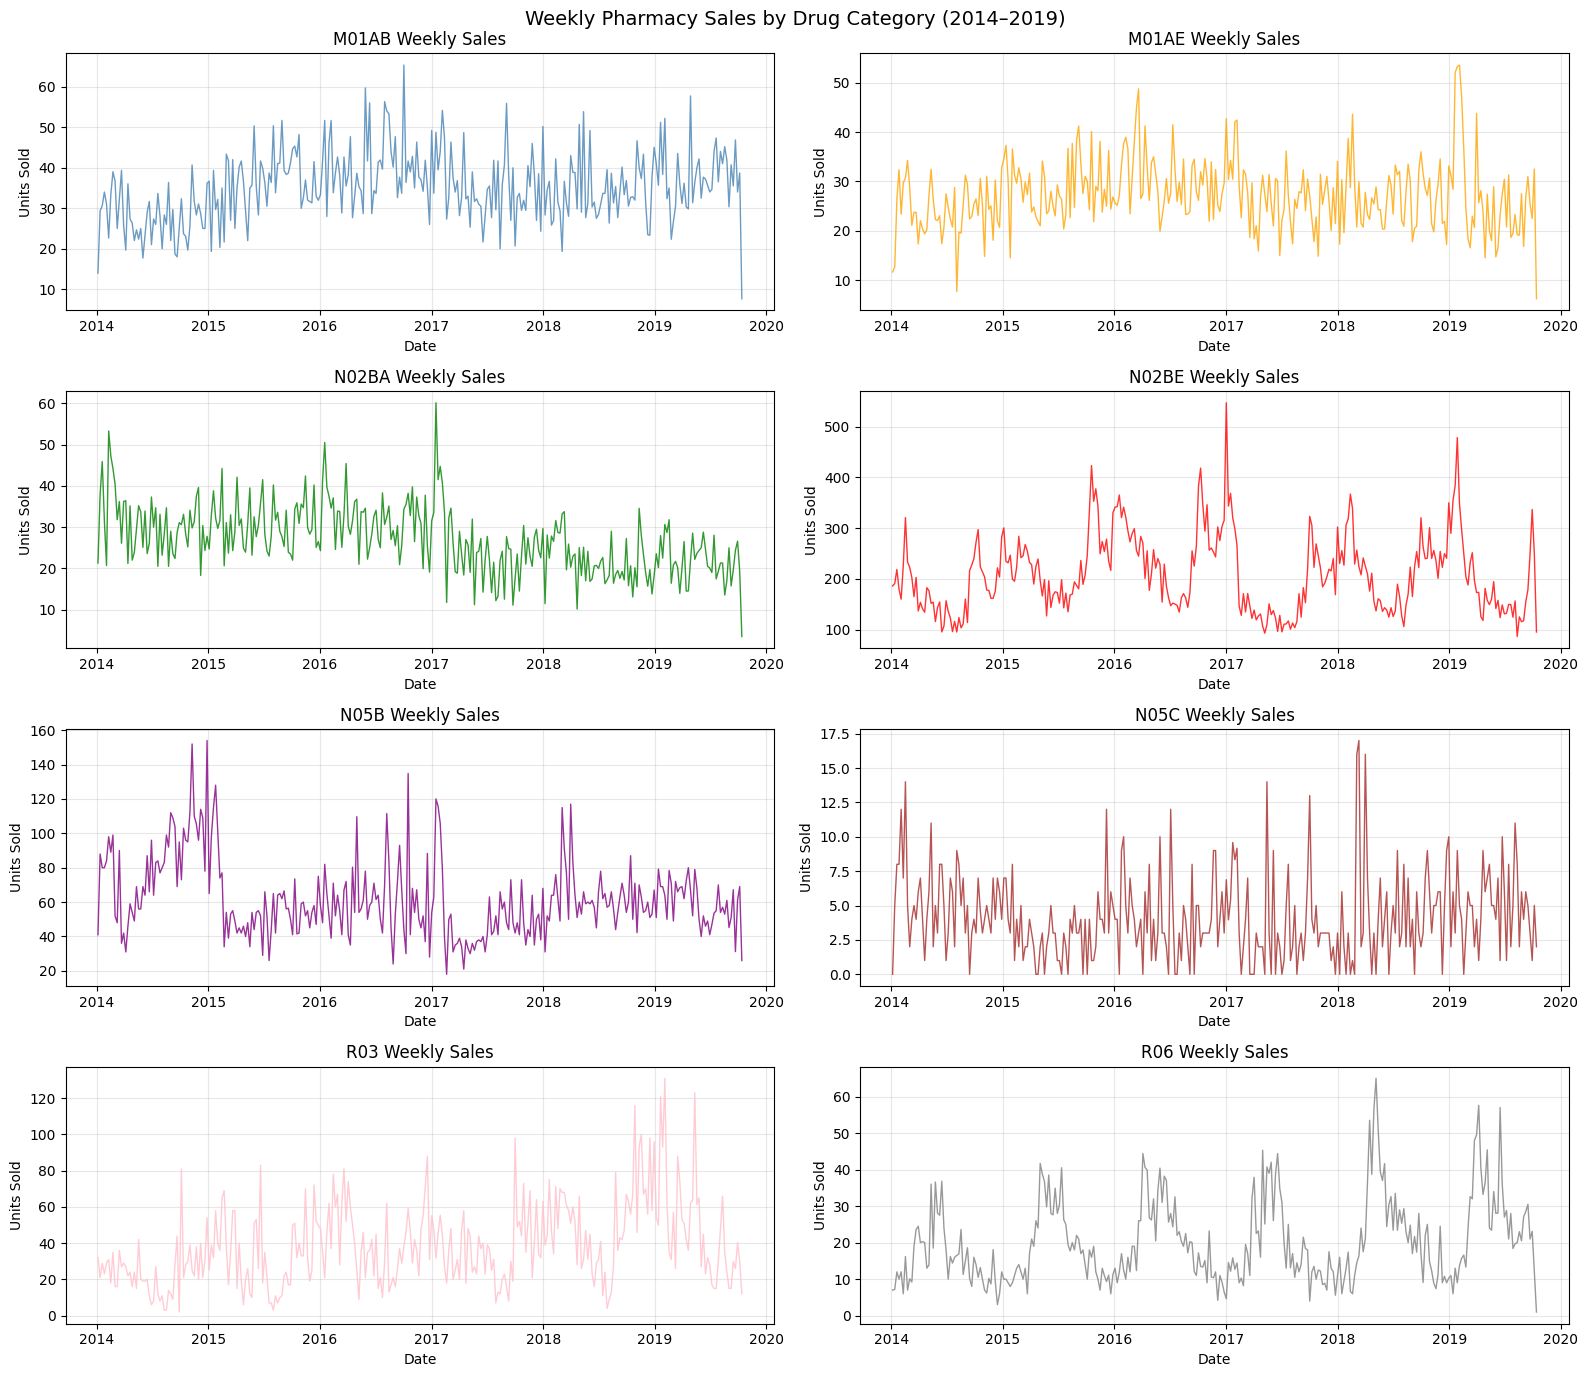

In [3]:
categories = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
colors = ['steelblue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray']

fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.flatten()

for i, (cat, color) in enumerate(zip(categories, colors)):
    axes[i].plot(df['datum'], df[cat], color=color, linewidth=1, alpha=0.8)
    axes[i].set_title(f'{cat} Weekly Sales')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Units Sold')
    axes[i].grid(alpha=0.3)

plt.suptitle('Weekly Pharmacy Sales by Drug Category (2014–2019)', fontsize=14)
plt.tight_layout()
plt.savefig('chart1_sales_trends.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight: R03 (respiratory) shows dramatic seasonal spikes every winter.
# N05B (sedatives) shows declining trend post-2015 — consistent with
# global regulatory tightening on benzodiazepine prescribing.
# N02BA (aspirin) declining trend reflects growing awareness of bleeding risk.

## 3. Seasonal Decomposition — R03 and N02BE

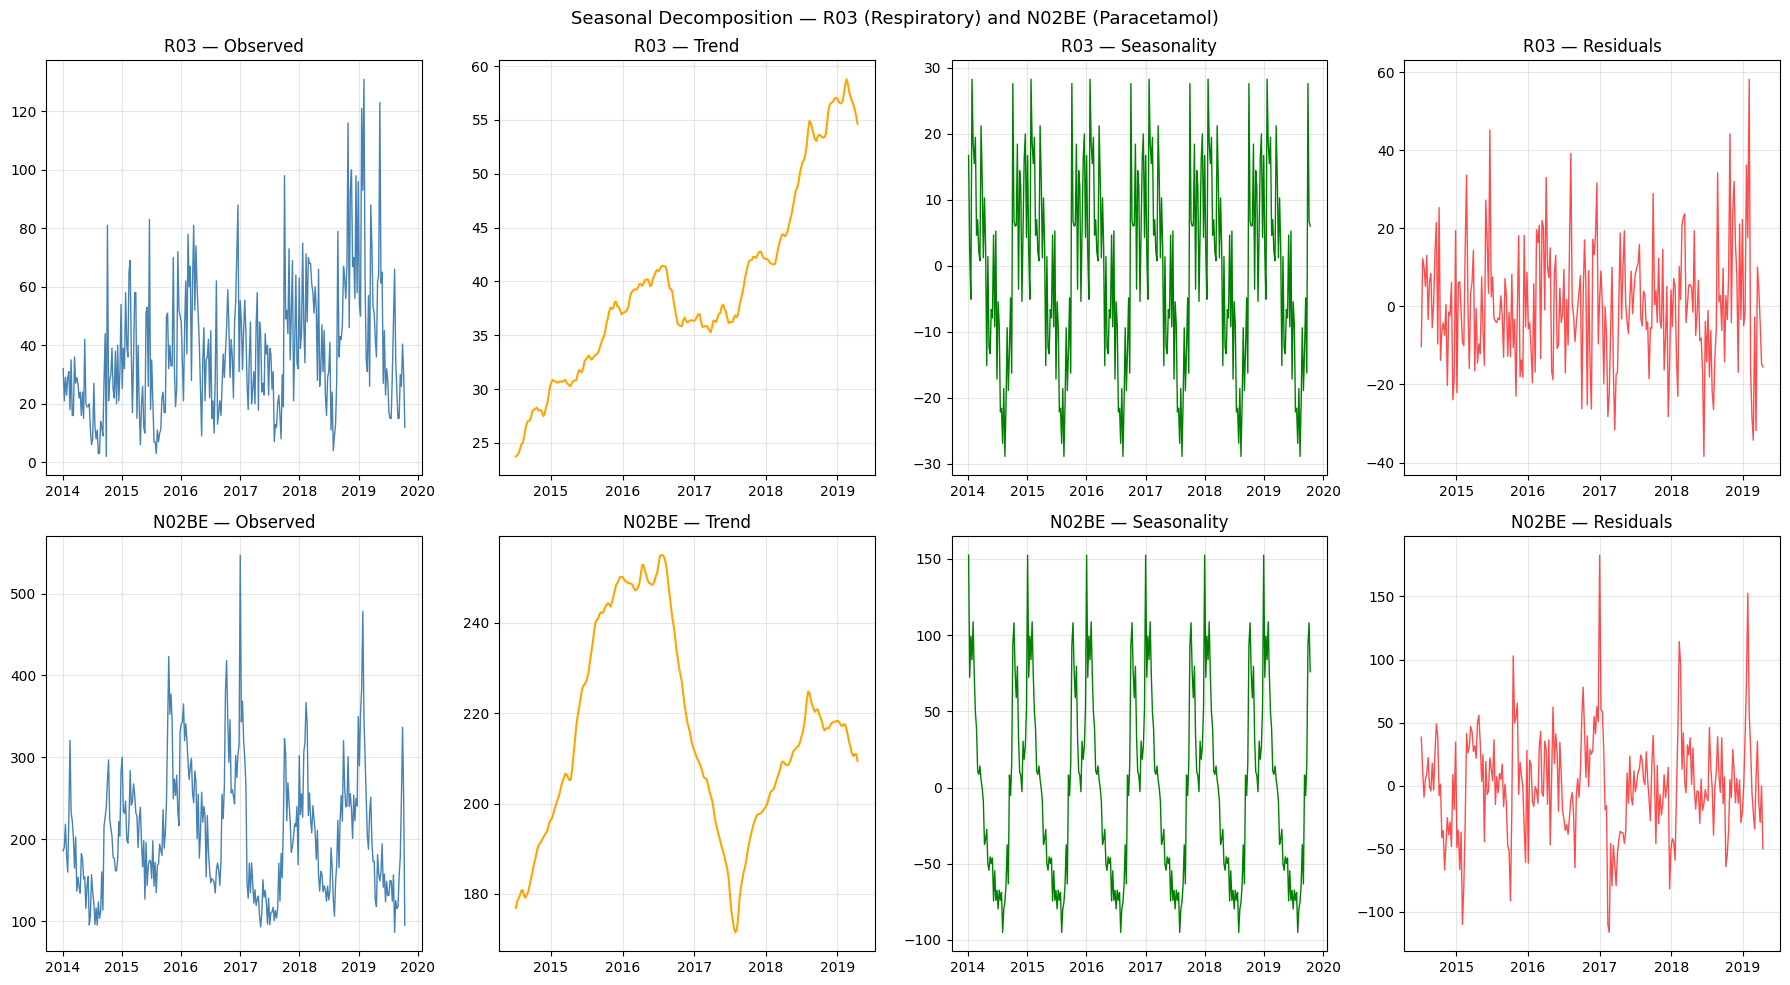

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for idx, cat in enumerate(['R03', 'N02BE']):
    ts = df.set_index('datum')[cat]
    decomp = seasonal_decompose(ts, model='additive', period=52)

    axes[idx,0].plot(decomp.observed, color='steelblue', linewidth=1)
    axes[idx,0].set_title(f'{cat} — Observed')
    axes[idx,0].grid(alpha=0.3)

    axes[idx,1].plot(decomp.trend, color='orange', linewidth=1.5)
    axes[idx,1].set_title(f'{cat} — Trend')
    axes[idx,1].grid(alpha=0.3)

    axes[idx,2].plot(decomp.seasonal, color='green', linewidth=1)
    axes[idx,2].set_title(f'{cat} — Seasonality')
    axes[idx,2].grid(alpha=0.3)

    axes[idx,3].plot(decomp.resid, color='red', linewidth=1, alpha=0.7)
    axes[idx,3].set_title(f'{cat} — Residuals')
    axes[idx,3].grid(alpha=0.3)

plt.suptitle('Seasonal Decomposition — R03 (Respiratory) and N02BE (Paracetamol)', fontsize=13)
plt.tight_layout()
plt.savefig('chart2_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight: R03 has both strong upward trend AND strong seasonality.
# N02BE shows a puzzling trend reversal post-2017 — possibly reflecting
# generic competition or prescribing pattern changes.
# Large residuals in 2019 R03 suggest an exogenous event (severe flu season).

## 4. Prophet Forecast — R03 (Respiratory)

21:25:45 - cmdstanpy - INFO - Chain [1] start processing
21:25:45 - cmdstanpy - INFO - Chain [1] done processing


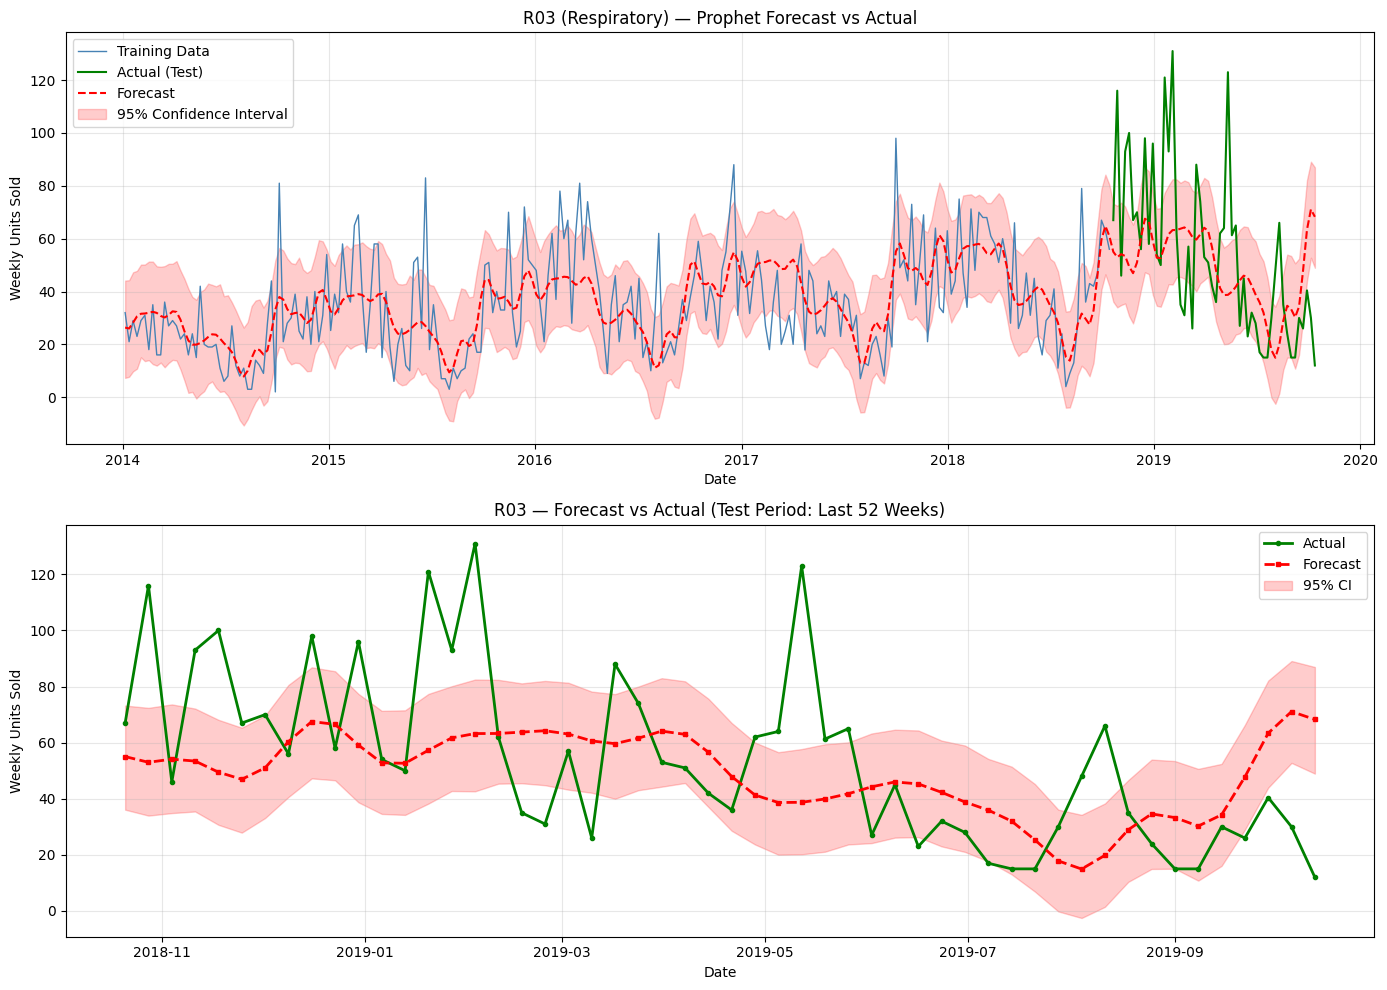

R03 Forecast Accuracy:
MAE:  23.54 units
RMSE: 29.98 units
MAPE: 56.5%


In [5]:
prophet_df = df[['datum', 'R03']].rename(columns={'datum': 'ds', 'R03': 'y'})
train = prophet_df.iloc[:-52]
test = prophet_df.iloc[-52:]

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)
model.fit(train)

future = model.make_future_dataframe(periods=52, freq='W')
forecast = model.predict(future)
test_forecast = forecast[forecast['ds'].isin(test['ds'])]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(train['ds'], train['y'], color='steelblue', linewidth=1, label='Training Data')
axes[0].plot(test['ds'], test['y'], color='green', linewidth=1.5, label='Actual (Test)')
axes[0].plot(forecast['ds'], forecast['yhat'], color='red',
             linewidth=1.5, linestyle='--', label='Forecast')
axes[0].fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                     alpha=0.2, color='red', label='95% Confidence Interval')
axes[0].set_title('R03 (Respiratory) — Prophet Forecast vs Actual')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Weekly Units Sold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(test['ds'], test['y'], color='green', linewidth=2,
             marker='o', markersize=3, label='Actual')
axes[1].plot(test_forecast['ds'], test_forecast['yhat'], color='red',
             linewidth=2, linestyle='--', marker='s', markersize=3, label='Forecast')
axes[1].fill_between(test_forecast['ds'],
                     test_forecast['yhat_lower'], test_forecast['yhat_upper'],
                     alpha=0.2, color='red', label='95% CI')
axes[1].set_title('R03 — Forecast vs Actual (Test Period: Last 52 Weeks)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Weekly Units Sold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('chart3_prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

mae = mean_absolute_error(test['y'], test_forecast['yhat'])
rmse = np.sqrt(mean_squared_error(test['y'], test_forecast['yhat']))
mape = np.mean(np.abs((test['y'].values - test_forecast['yhat'].values) /
                       test['y'].values)) * 100

print(f"R03 Forecast Accuracy:")
print(f"MAE:  {mae:.2f} units")
print(f"RMSE: {rmse:.2f} units")
print(f"MAPE: {mape:.1f}%")

# Insight: Prophet captures seasonal patterns but MAPE of 56.5% reflects
# inability to predict extreme demand spikes (flu epidemics).
# For inventory planning, the upper confidence interval is more useful
# than point estimates — stock to upper CI to avoid respiratory drug stockouts.

## 5. Forecast All Drug Categories

In [6]:
forecast_results = {}

for cat in categories:
    prophet_df = df[['datum', cat]].rename(columns={'datum': 'ds', cat: 'y'})
    train = prophet_df.iloc[:-52]
    test = prophet_df.iloc[-52:]

    m = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                daily_seasonality=False, seasonality_mode='multiplicative')
    m.fit(train)

    future = m.make_future_dataframe(periods=52, freq='W')
    fc = m.predict(future)
    test_fc = fc[fc['ds'].isin(test['ds'])]

    mae = mean_absolute_error(test['y'], test_fc['yhat'])
    rmse = np.sqrt(mean_squared_error(test['y'], test_fc['yhat']))
    mape = np.mean(np.abs((test['y'].values - test_fc['yhat'].values) /
                           test['y'].values)) * 100

    forecast_results[cat] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape,
                              'test': test, 'forecast': test_fc}
    mape_str = f"{mape:.1f}%" if mape != float('inf') else "N/A"
    print(f"{cat}: MAE={mae:.1f} | RMSE={rmse:.1f} | MAPE={mape_str}")

21:25:46 - cmdstanpy - INFO - Chain [1] start processing
21:25:46 - cmdstanpy - INFO - Chain [1] done processing
21:25:46 - cmdstanpy - INFO - Chain [1] start processing
21:25:46 - cmdstanpy - INFO - Chain [1] done processing


M01AB: MAE=7.9 | RMSE=9.8 | MAPE=24.6%


21:25:46 - cmdstanpy - INFO - Chain [1] start processing
21:25:46 - cmdstanpy - INFO - Chain [1] done processing


M01AE: MAE=6.7 | RMSE=8.9 | MAPE=30.0%


21:25:47 - cmdstanpy - INFO - Chain [1] start processing
21:25:47 - cmdstanpy - INFO - Chain [1] done processing


...

N05B: MAE=12.1 | RMSE=15.7 | MAPE=21.2%


21:25:47 - cmdstanpy - INFO - Chain [1] start processing
21:25:47 - cmdstanpy - INFO - Chain [1] done processing


N05C: MAE=2.6 | RMSE=3.3 | MAPE=N/A


21:25:48 - cmdstanpy - INFO - Chain [1] start processing
21:25:48 - cmdstanpy - INFO - Chain [1] done processing


R03: MAE=23.5 | RMSE=30.0 | MAPE=56.5%
R06: MAE=6.7 | RMSE=9.2 | MAPE=58.6%


## 6. Forecast Accuracy Comparison

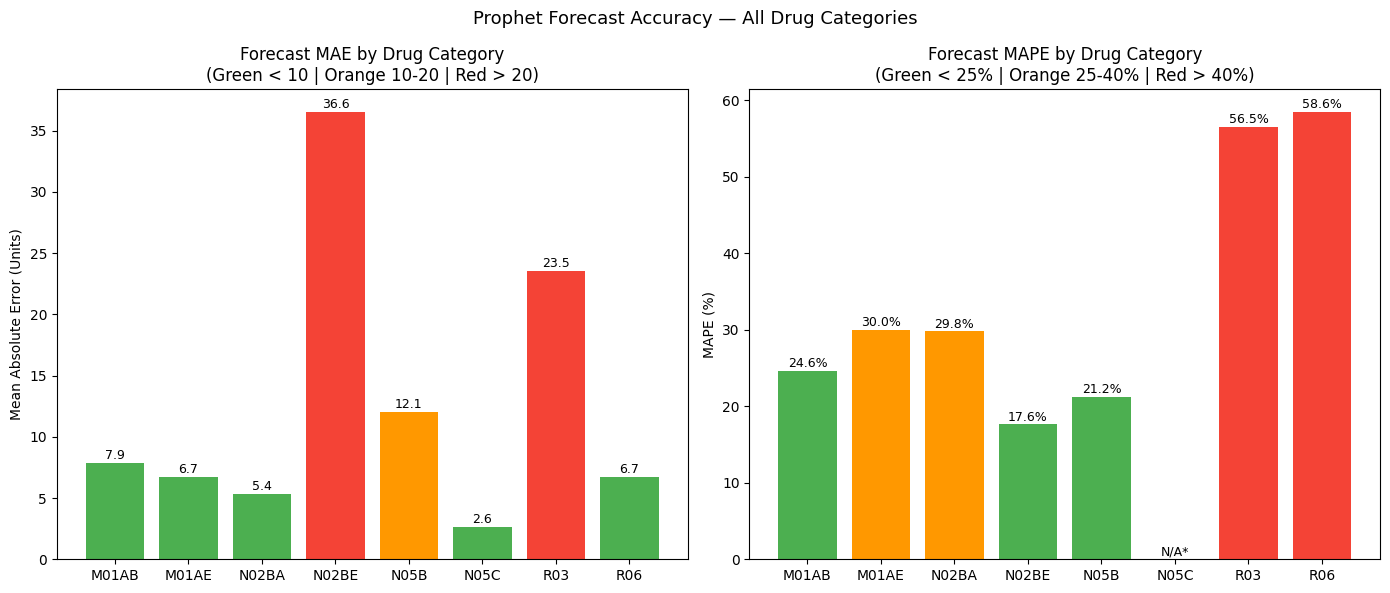

* N05C MAPE undefined due to zero sales weeks


In [7]:
summary = pd.DataFrame({
    cat: {
        'MAE': forecast_results[cat]['MAE'],
        'MAPE': forecast_results[cat]['MAPE']
        if forecast_results[cat]['MAPE'] != float('inf') else np.nan
    }
    for cat in categories
}).T

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_mae = ['#4CAF50' if v < 10 else '#FF9800' if v < 20 else '#F44336'
              for v in summary['MAE']]
axes[0].bar(summary.index, summary['MAE'], color=colors_mae)
axes[0].set_title('Forecast MAE by Drug Category\n(Green < 10 | Orange 10-20 | Red > 20)')
axes[0].set_ylabel('Mean Absolute Error (Units)')
for i, v in enumerate(summary['MAE']):
    axes[0].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=9)

mape_vals = summary['MAPE'].fillna(0)
colors_mape = ['#4CAF50' if v < 25 else '#FF9800' if v < 40 else '#F44336'
               for v in mape_vals]
axes[1].bar(summary.index, mape_vals, color=colors_mape)
axes[1].set_title('Forecast MAPE by Drug Category\n(Green < 25% | Orange 25-40% | Red > 40%)')
axes[1].set_ylabel('MAPE (%)')
for i, v in enumerate(mape_vals):
    label = f'{v:.1f}%' if v > 0 else 'N/A*'
    axes[1].text(i, v + 0.5, label, ha='center', fontsize=9)

plt.suptitle('Prophet Forecast Accuracy — All Drug Categories', fontsize=13)
plt.tight_layout()
plt.savefig('chart4_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("* N05C MAPE undefined due to zero sales weeks")

## 7. Inventory Strategy Recommendations

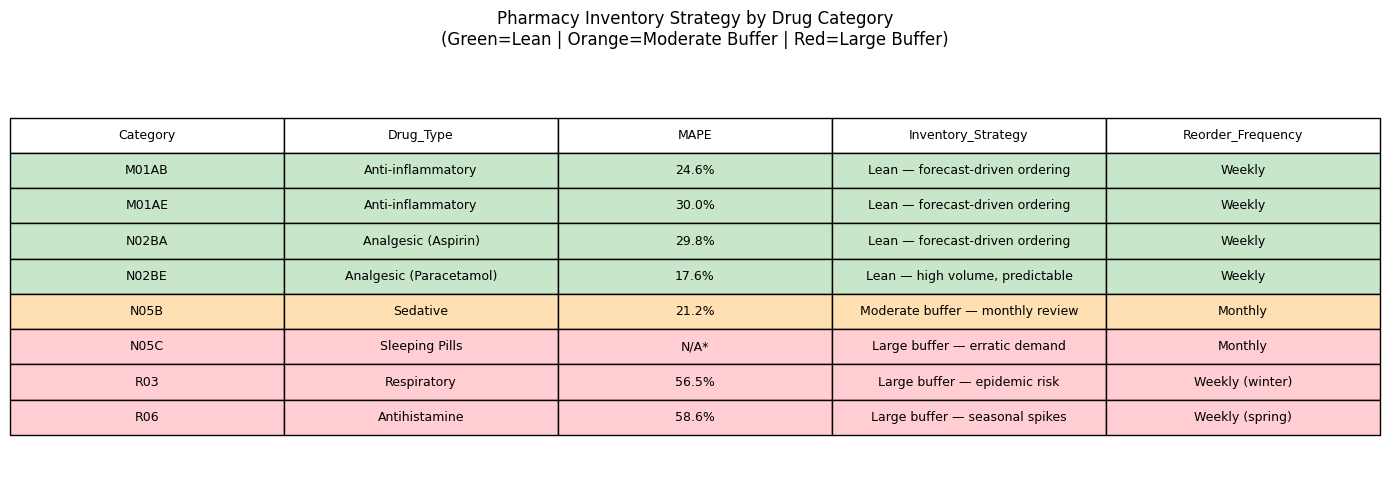

In [8]:
strategy = pd.DataFrame({
    'Category': categories,
    'Drug_Type': ['Anti-inflammatory','Anti-inflammatory','Analgesic (Aspirin)',
                  'Analgesic (Paracetamol)','Sedative','Sleeping Pills',
                  'Respiratory','Antihistamine'],
    'MAPE': [f"{forecast_results[c]['MAPE']:.1f}%"
             if forecast_results[c]['MAPE'] != float('inf') else 'N/A*'
             for c in categories],
    'Inventory_Strategy': [
        'Lean — forecast-driven ordering',
        'Lean — forecast-driven ordering',
        'Lean — forecast-driven ordering',
        'Lean — high volume, predictable',
        'Moderate buffer — monthly review',
        'Large buffer — erratic demand',
        'Large buffer — epidemic risk',
        'Large buffer — seasonal spikes'
    ],
    'Reorder_Frequency': [
        'Weekly','Weekly','Weekly','Weekly',
        'Monthly','Monthly','Weekly (winter)','Weekly (spring)'
    ]
})

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')
table = ax.table(cellText=strategy.values, colLabels=strategy.columns,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

colors_map = {
    'Lean — forecast-driven ordering': '#C8E6C9',
    'Lean — high volume, predictable': '#C8E6C9',
    'Moderate buffer — monthly review': '#FFE0B2',
    'Large buffer — erratic demand': '#FFCDD2',
    'Large buffer — epidemic risk': '#FFCDD2',
    'Large buffer — seasonal spikes': '#FFCDD2'
}
for i, row in strategy.iterrows():
    color = colors_map.get(row['Inventory_Strategy'], 'white')
    for j in range(len(strategy.columns)):
        table[i+1, j].set_facecolor(color)

plt.title('Pharmacy Inventory Strategy by Drug Category\n'
          '(Green=Lean | Orange=Moderate Buffer | Red=Large Buffer)', fontsize=12, pad=20)
plt.tight_layout()
plt.savefig('chart5_inventory_strategy.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight: Forecastability inversely correlates with seasonality intensity.
# Stable chronic medications are most predictable — enabling lean inventory.
# Seasonal drugs require safety stock buffers rather than precise point forecasts.
# This directly informs Aduru Analytics inventory optimization recommendations.

## 8. Conclusions

### Forecast Performance Summary

| Category | Drug Type | MAPE | Strategy |
|---|---|---|---|
| N02BE | Paracetamol | 17.6% | Lean — weekly ordering |
| N05B | Sedative | 21.2% | Moderate buffer |
| M01AB | Anti-inflammatory | 24.6% | Lean — weekly ordering |
| N02BA | Aspirin | 29.8% | Lean — weekly ordering |
| M01AE | Anti-inflammatory | 30.0% | Lean — weekly ordering |
| R03 | Respiratory | 56.5% | Large buffer — epidemic risk |
| R06 | Antihistamine | 58.6% | Large buffer — seasonal |
| N05C | Sleeping Pills | N/A | Large buffer — erratic |

### Key Findings

| Finding | Implication |
|---|---|
| **R03 trend growing 2x over 6 years** | Increasing respiratory drug demand requires proactive stock planning |
| **N05B declining trend post-2015** | Regulatory tightening on sedatives visible in dispensing data |
| **Chronic meds most forecastable** | Lean inventory strategies safe for anti-inflammatories and paracetamol |
| **Seasonal drugs unpredictable** | Buffer stock essential — flu epidemics impossible to forecast precisely |
| **Upper CI more useful than point forecast** | For high-MAPE categories, plan to the upper confidence bound |

### Aduru Analytics Application
This forecasting framework is directly applicable to KAM AID Pharmacy's three branches in Greater Accra — enabling data-driven procurement decisions that reduce stockouts during peak illness seasons while minimizing working capital tied up in excess inventory.

---

**Data Source:** Pharmaceutical Sales Dataset via Kaggle  
**Analysis by:** Afriyie Karikari Bempah, PharmD | [LinkedIn](https://linkedin.com/in/afriyiekarikaribempah) | [GitHub](https://github.com/akbempah1)